In [17]:
import numpy as numpy
import pandas as pd 
import nltk
import matplotlib.pyplot as plt  # For data visualization
%matplotlib inline

# Importing WordCloud for text visualization
from wordcloud import WordCloud, STOPWORDS


In [2]:
from nltk.corpus import stopwords    # For stopwords

# Downloading NLTK data
nltk.download('stopwords')   # Downloading stopwords data
nltk.download('punkt')       # Downloading tokenizer data

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sachi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sachi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
# Read the CSV file
df = pd.read_csv('spam.csv')

# Display the first few rows of the DataFrame
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(columns = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace = True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
# Rename the columns name
df.rename(columns = {'v1': 'target', 'v2': 'text'}, inplace = True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
#check duplicate values
df.duplicated().sum()

403

In [9]:
#remove Duplicate
df = df.drop_duplicates(keep = 'first')
len(df)

5169

In [10]:
df.isna().sum()

target    0
text      0
dtype: int64

Feature Enggineering


In [11]:
from nltk.stem import WordNetLemmatizer

In [12]:
import string

In [13]:
lema = WordNetLemmatizer()
import re
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    # Removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    # Removing stop words and punctuation
    text = y[:]
    y.clear()

    # Loop through the tokens and remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    for i in text:
        y.append(lema.lemmatize(i))
    
    return " ".join(y)  

In [14]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazy available bugis n great world la e buffet cine got amore wat go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat'

In [15]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say u dun say ...
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though nah i d...


Train Test Split

In [16]:
#splitting into train test dataset
from sklearn.model_selection import train_test_split
X = df['transformed_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)
X_train.shape, X_test.shape 


((4135,), (1034,))

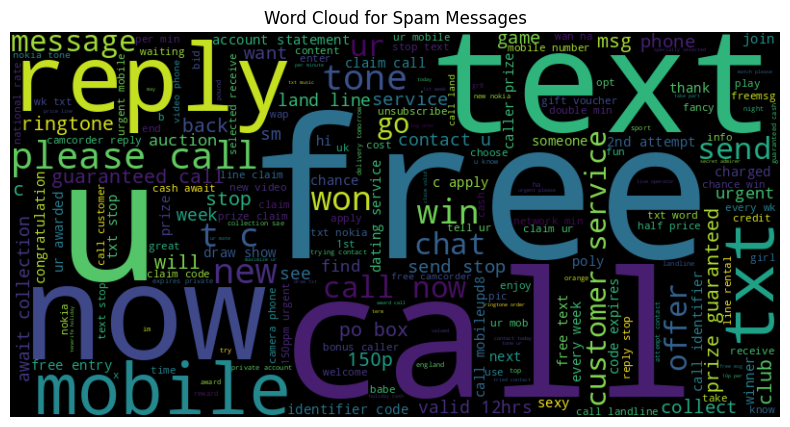

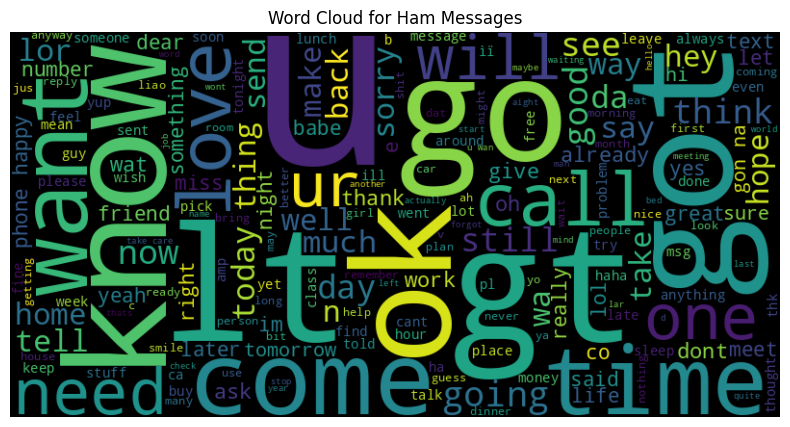

In [19]:
# Function to generate word cloud
def generate_wordcloud(text,Title):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800, 
                          height=400,
                          stopwords=set(STOPWORDS), 
                          background_color='black').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(Title)
    plt.show()

# Generating word cloud for spam messages
spam_messages = df[df['target'] == 1]['transformed_text']
generate_wordcloud(spam_messages, "Word Cloud for Spam Messages")
# Generating word cloud for ham messages
ham_messages = df[df['target'] == 0]['transformed_text']
generate_wordcloud(ham_messages, "Word Cloud for Ham Messages")


In [20]:
#utilizing BERT model for feature extraction
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased') 


In [21]:
#check the distribution of target variable
df['target'].value_counts()


target
0    4516
1     653
Name: count, dtype: int64

In [22]:
import torch

In [24]:
#applying BERT tokenizer and model to get features
def bert_encode(texts, tokenizer, max_len=512):
    input_ids = []
    attention_masks = []

    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_len,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True,
            padding='max_length'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    return torch.cat(input_ids, dim=0), torch.cat(attention_masks, dim=0)

train_inputs, train_masks = bert_encode(X_train, tokenizer, max_len=64)
test_inputs, test_masks = bert_encode(X_test, tokenizer, max_len=64)

In [25]:
#using cuda if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [26]:
#setting up DataLoader for batching
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
train_data = TensorDataset(train_inputs, train_masks, torch.tensor(y_train.values))
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=32) 
test_data = TensorDataset(test_inputs, test_masks, torch.tensor(y_test.values))
test_sampler = SequentialSampler(test_data)
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=32)


In [ ]:
#Training the model
from torch import nn, optim

class SpamClassifier(nn.Module):
    def __init__(self, bert_model):
        super(SpamClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)
        self.linear = nn.Linear(bert_model.config.hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        final_output = self.sigmoid(linear_output)
        return final_output
    

model = SpamClassifier(model)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
loss_fn = nn.BCELoss()
epochs = 4


for epoch in range(epochs):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_dataloader):
        b_input_ids = batch[0].to(device)
        b_attention_mask = batch[1].to(device)
        b_labels = batch[2].to(device).float().unsqueeze(1)
        
        model.zero_grad()
        outputs = model(b_input_ids, b_attention_mask)
        loss = loss_fn(outputs, b_labels)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    
    avg_train_loss = total_loss / len(train_dataloader)
    print(f'Epoch {epoch + 1}, Loss: {avg_train_loss}')


Epoch 1, Loss: 0.20000002228010158
Epoch 2, Loss: 0.059641257838274425
Epoch 3, Loss: 0.03759172368400659
Epoch 4, Loss: 0.02240611219133895


In [29]:
#evaluating the model
model.eval()

SpamClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

In [30]:
#classification report
from sklearn.metrics import classification_report
y_pred = []
y_true = []
for batch in test_dataloader:
    b_input_ids = batch[0].to(device)
    b_attention_mask = batch[1].to(device)
    b_labels = batch[2].to(device).float().unsqueeze(1)
    
    with torch.no_grad():
        outputs = model(b_input_ids, b_attention_mask)
    
    preds = (outputs.cpu().numpy() > 0.5).astype(int)
    y_pred.extend(preds)
    y_true.extend(b_labels.cpu().numpy())
print(classification_report(y_true, y_pred, target_names=['Ham', 'Spam']))


              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       896
        Spam       0.94      0.96      0.95       138

    accuracy                           0.99      1034
   macro avg       0.97      0.98      0.97      1034
weighted avg       0.99      0.99      0.99      1034



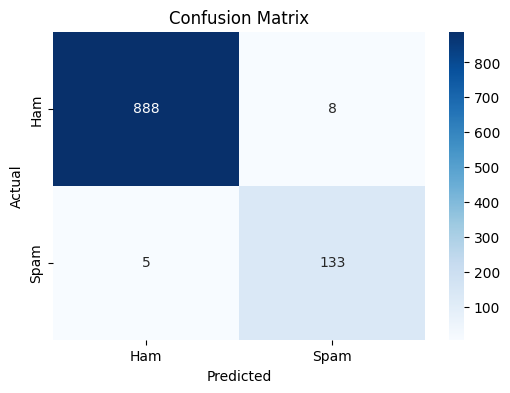

In [31]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#saving the model
torch.save(model.state_dict(), 'spam_classifier_bert.pth')
